# Week 1: Data Exploration & Initial Analysis

## Objective
Load the tech salary dataset, understand its structure, and identify key patterns.
This notebook will be converted to Jupyter format.

## Import Libraries

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

print("Libraries imported successfully!")

Libraries imported successfully!


## 1. Load & Validate Data

In [3]:
# Load the dataset
df = pd.read_csv('../data/raw/tech_jobs_salaries.csv')

print("=" * 70)
print("DATASET OVERVIEW")
print("=" * 70)
print(f"\n Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\n Columns:\n{df.columns.tolist()}")
print(f"\n Data Types:\n{df.dtypes}")
print(f"\n First 3 rows:")
print(df.head(3))

DATASET OVERVIEW

 Shape: 200,000 rows × 17 columns

 Columns:
['job_title', 'company_size', 'employment_type', 'experience_level', 'years_experience', 'education_level', 'country', 'salary_local_currency', 'currency', 'remote_type', 'primary_skill', 'secondary_skill', 'work_hours_per_week', 'job_satisfaction_score', 'company_rating', 'age', 'gender']

 Data Types:
job_title                     str
company_size                  str
employment_type               str
experience_level              str
years_experience            int64
education_level               str
country                       str
salary_local_currency       int64
currency                      str
remote_type                   str
primary_skill                 str
secondary_skill               str
work_hours_per_week         int64
job_satisfaction_score    float64
company_rating            float64
age                         int64
gender                        str
dtype: object

 First 3 rows:
             job_title c

## 2. Data Quality Check

In [4]:
# Missing data
print("\n" + "=" * 70)
print("MISSING DATA")
print("=" * 70)
missing = df.isnull().sum()
if missing.sum() == 0:
    print(" No missing values found!")
else:
    print(missing[missing > 0])

# Duplicates
print(f"\n Duplicate rows: {df.duplicated().sum()}")


MISSING DATA
 No missing values found!

 Duplicate rows: 0


## 3. Numeric Summary

In [5]:
print("\n" + "=" * 70)
print("Numeric Summary")
print("=" * 70)
print(df.describe())


Numeric Summary
       years_experience  salary_local_currency  work_hours_per_week  \
count     200000.000000           2.000000e+05        200000.000000   
mean           9.996435           1.482697e+06            47.478255   
std            6.063410           3.851758e+06             7.493073   
min            0.000000           3.150200e+04            35.000000   
25%            5.000000           8.981650e+04            41.000000   
50%           10.000000           1.355590e+05            47.000000   
75%           15.000000           2.294970e+05            54.000000   
max           20.000000           2.519841e+07            60.000000   

       job_satisfaction_score  company_rating            age  
count           200000.000000   200000.000000  200000.000000  
mean                 3.748127        3.897402      38.005910  
std                  0.723096        0.637670      10.110063  
min                  2.500000        2.800000      21.000000  
25%                  3.10000

## 4. Categorical Overview

In [6]:
print("\n" + "=" * 70)
print("Categorical Columns")
print("=" * 70)

# Expreience Level
print("\nExperience Level Distribution:")
print(df['experience_level'].value_counts())

# Company Size
print("\nCompany Size Distribution:")
print(df['company_size'].value_counts())

# Countries
print("\nTop 10 Countries:")
print(df['country'].value_counts().head(10))

# Primary Skills
print("\nTop 15 Primary Skills:")
print(df['primary_skill'].value_counts().head(15))

# Remote Type
print("\nRemote Work Type:")
print(df['remote_type'].value_counts())

# Gender
print("\nGender Distribution:")
print(df['gender'].value_counts())


Categorical Columns

Experience Level Distribution:
experience_level
Senior    50456
Entry     50133
Mid       50045
Lead      49366
Name: count, dtype: int64

Company Size Distribution:
company_size
Mid-size      50317
Startup       50040
Enterprise    49939
SME           49704
Name: count, dtype: int64

Top 10 Countries:
country
France         20171
Canada         20113
Japan          20069
Germany        20015
Netherlands    20010
UK             20010
India          20003
Singapore      19962
USA            19909
Australia      19738
Name: count, dtype: int64

Top 15 Primary Skills:
primary_skill
Docker        12629
JavaScript    12586
React         12558
C++           12531
Node.js       12523
NoSQL         12512
Linux         12500
AWS           12499
Kubernetes    12492
Python        12492
PyTorch       12470
Java          12470
GCP           12469
SQL           12459
Azure         12410
Name: count, dtype: int64

Remote Work Type:
remote_type
Hybrid    66807
Remote    66776
Ons

## 5. Salary Analysis


SALARY DISTRIBUTION

Salary Range: $31,502 to $25,198,412
Mean Salary: $1,482,697
Median Salary: $135,559
Std Dev: $3,851,758

Potential outliers: 39595 records (19.80%)


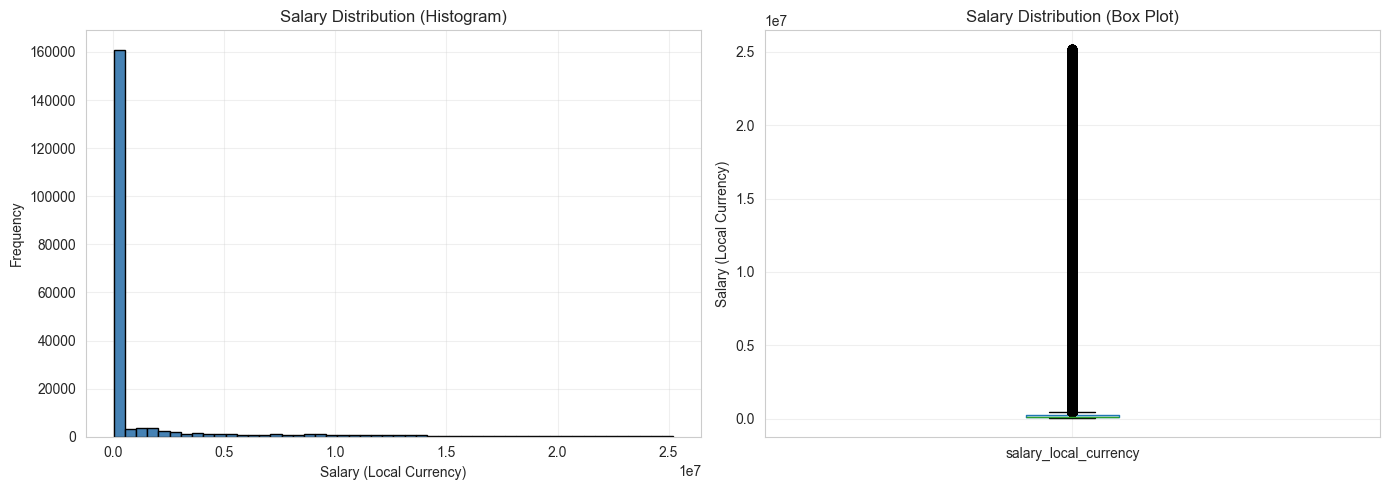

In [7]:
print("\n" + "=" * 70)
print("SALARY DISTRIBUTION")
print("=" * 70)

# Basic stats
print(f"\nSalary Range: ${df['salary_local_currency'].min():,.0f} to ${df['salary_local_currency'].max():,.0f}")
print(f"Mean Salary: ${df['salary_local_currency'].mean():,.0f}")
print(f"Median Salary: ${df['salary_local_currency'].median():,.0f}")
print(f"Std Dev: ${df['salary_local_currency'].std():,.0f}")

# Check for outliers
q1 = df['salary_local_currency'].quantile(0.25)
q3 = df['salary_local_currency'].quantile(0.75)
iqr = q3 - q1
outliers = df[(df['salary_local_currency'] < (q1 - 1.5 * iqr)) | (df['salary_local_currency'] > (q3 + 1.5 * iqr))]
print(f"\nPotential outliers: {len(outliers)} records ({len(outliers)/len(df) * 100:.2f}%)")

# Distribution plot
fig, axes = plt.subplots(1, 2, figsize = ( 14, 5))

# Histogram
axes[0].hist(df['salary_local_currency'], bins=50, color='steelblue', edgecolor='black')
axes[0].set_xlabel('Salary (Local Currency)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Salary Distribution (Histogram)')
axes[0].grid(alpha=0.3)

# Box plot
df.boxplot(column='salary_local_currency', ax=axes[1])
axes[1].set_ylabel('Salary (Local Currency)')
axes[1].set_title('Salary Distribution (Box Plot)')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/01_salary_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

## 6. Quick Insights - Skills and Salary


SALARY BY SKILL (Top 10)
               job_count  avg_salary  median_salary
primary_skill                                      
C++                12531   1432466.0       136733.0
TensorFlow         12400   1437329.0       136523.0
SQL                12459   1453424.0       136481.0
Azure              12410   1507174.0       136432.0
Docker             12629   1543741.0       136424.0
Node.js            12523   1504746.0       136371.0
Java               12470   1459353.0       135646.0
JavaScript         12586   1467649.0       135629.0
NoSQL              12512   1503397.0       135488.0
Python             12492   1491592.0       135346.0


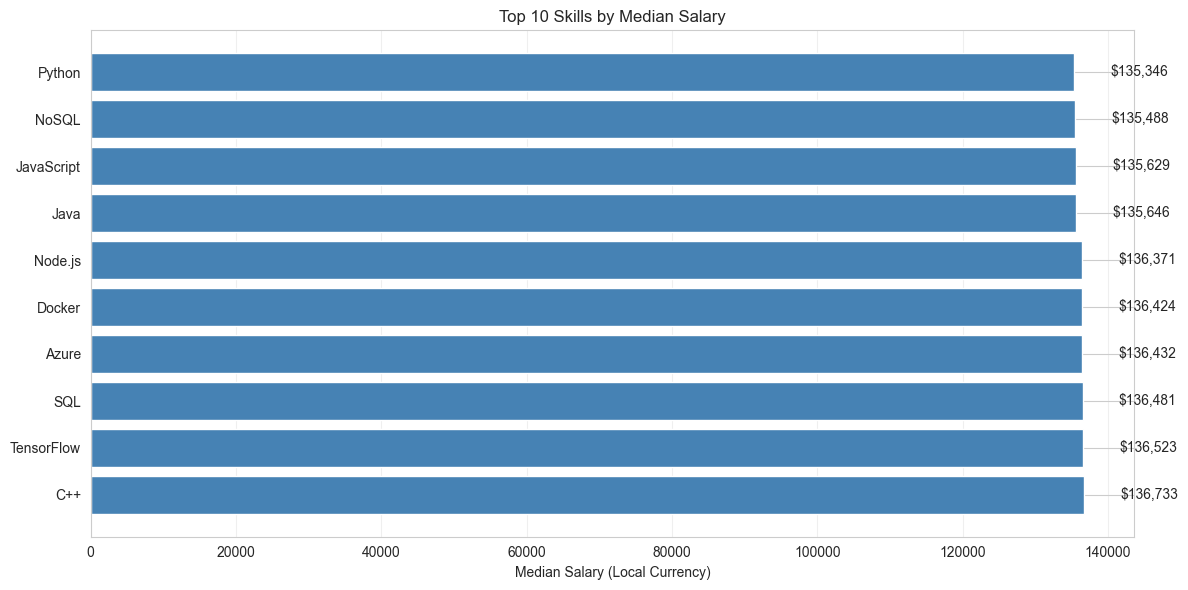

In [8]:
# Average salary by skill
skill_salary = df.groupby('primary_skill').agg({
    'salary_local_currency': ['count', 'mean', 'median']
}).round(0)

skill_salary.columns = ['job_count', 'avg_salary', 'median_salary']
skill_salary = skill_salary.sort_values('median_salary', ascending=False)

print("\n" + "=" * 70)
print("SALARY BY SKILL (Top 10)")
print("=" * 70)
print(skill_salary.head(10))

# Visualization
fig, ax = plt.subplots(figsize=(12, 6))
top_10_skills = skill_salary.head(10)
ax.barh(top_10_skills.index, top_10_skills['median_salary'], color='steelblue')
ax.set_xlabel('Median Salary (Local Currency)')
ax.set_title('Top 10 Skills by Median Salary')
ax.grid(alpha=0.3, axis='x')

for i, v in enumerate(top_10_skills['median_salary']):
    ax.text(v + 5000, i, f'${v:,.0f}', va='center')

plt.tight_layout()
plt.savefig('../reports/02_skills_salary.png', dpi=300, bbox_inches='tight')
plt.show()

## 7. Experience Level and Salary


Salary by Experience Level
                  job_count  avg_salary  median_salary  avg_years
experience_level                                                 
Entry                 50133    848381.0        79169.0       10.0
Mid                   50045   1187371.0       112630.0       10.0
Senior                50456   1686114.0       158112.0       10.0
Lead                  49366   2218347.0       203696.0       10.0


<function matplotlib.pyplot.show(close=None, block=None)>

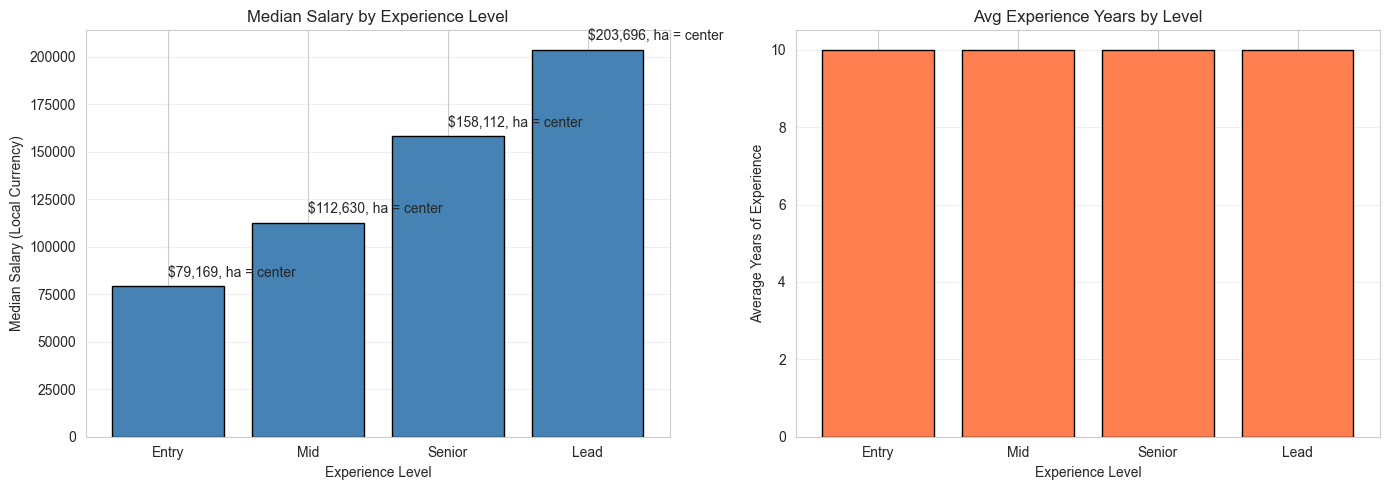

In [9]:
exp_salary = df.groupby('experience_level').agg({'salary_local_currency': ['count', 'mean', 'median'], 'years_experience': 'mean'}).round(0)

exp_salary.columns = ['job_count', 'avg_salary', 'median_salary', 'avg_years']
experience_order = ['Entry', 'Mid', 'Senior', 'Lead']
exp_salary = exp_salary.reindex(experience_order)

print("\n" + "=" * 70)
print("Salary by Experience Level")
print("=" * 70)
print(exp_salary)

# Visualization
fig, axes = plt.subplots(1, 2, figsize = (14, 5))

# Salary by experience
axes[0].bar(exp_salary.index, exp_salary['median_salary'], color = 'steelblue', edgecolor = 'black')
axes[0].set_ylabel('Median Salary (Local Currency)')
axes[0].set_xlabel("Experience Level")
axes[0].set_title("Median Salary by Experience Level")
axes[0].grid(alpha = 0.3, axis = 'y')

for i, (idx, row) in enumerate(exp_salary.iterrows()):
    axes[0].text(i, row['median_salary'] + 5000,
    f"${row['median_salary']:,.0f}, ha = center")

# Years of Experience by Level
axes[1].bar(exp_salary.index, exp_salary['avg_years'], color = 'coral', edgecolor = 'black')
axes[1].set_ylabel("Average Years of Experience")
axes[1].set_xlabel("Experience Level")
axes[1].set_title("Avg Experience Years by Level")
axes[1].grid(alpha = 0.3, axis = 'y')

plt.tight_layout()
plt.savefig('../reports/03_experience_salary.png', dpi = 300, bbox_inches = 'tight')
plt.show

## 8. Company Size & Salary


SALARY BY COMPANY SIZE
              job_count  avg_salary  median_salary  avg_satisfaction
company_size                                                        
Startup           50040   1497200.0       135964.0               4.0
Mid-size          50317   1461002.0       135590.0               4.0
Enterprise        49939   1489248.0       135502.0               4.0
SME               49704   1483475.0       135255.0               4.0


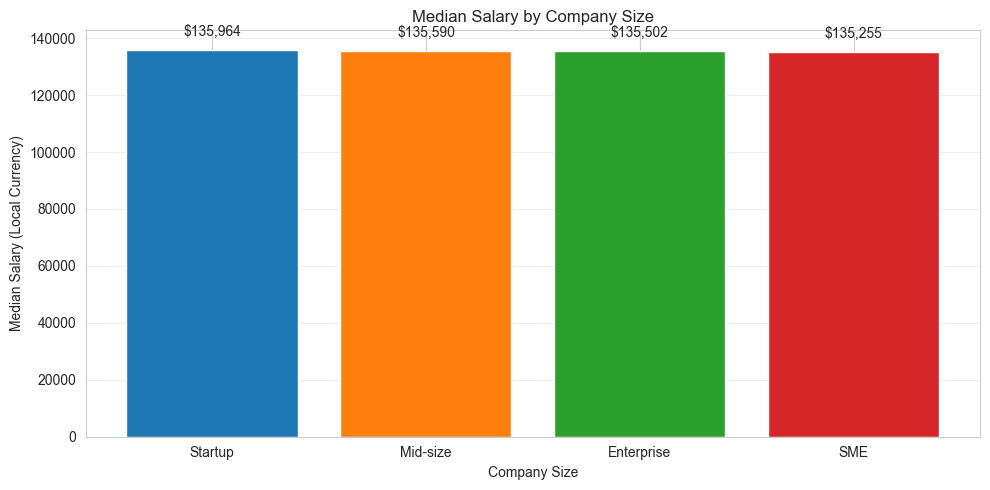

In [12]:
## Salary by company size
company_salary = df.groupby('company_size').agg({
    'salary_local_currency': ['count', 'mean', 'median'],
    'job_satisfaction_score': 'mean'
}).round(0)

company_salary.columns = ['job_count', 'avg_salary', 'median_salary', 'avg_satisfaction']
company_salary = company_salary.sort_values('median_salary', ascending=False)

print("\n" + "=" * 70)
print("SALARY BY COMPANY SIZE")
print("=" * 70)
print(company_salary)

# Visualization
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(company_salary.index, company_salary['median_salary'], color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
ax.set_ylabel('Median Salary (Local Currency)')
ax.set_xlabel('Company Size')
ax.set_title('Median Salary by Company Size')
ax.grid(alpha=0.3, axis='y')

for i, (idx, row) in enumerate(company_salary.iterrows()):
    ax.text(i, row['median_salary'] + 5000, f"${row['median_salary']:,.0f}", ha='center')

plt.tight_layout()
plt.savefig('../reports/04_company_size_salary.png', dpi=300, bbox_inches='tight')
plt.show()


## 9. Geographic Analysis


SALARY BY COUNTRY
             job_count  avg_salary  median_salary  avg_satisfaction
country                                                            
Japan            20069  11702538.0     10618381.0               4.0
India            20003   2073435.0      1825931.0               4.0
USA              19909    152950.0       140352.0               4.0
Singapore        19962    140341.0       127360.0               4.0
Australia        19738    137438.0       127210.0               4.0
Canada           20113    128190.0       118632.0               4.0
Netherlands      20010    122575.0       112724.0               4.0
Germany          20015    119414.0       109711.0               4.0
UK               20010    109492.0       100848.0               4.0
France           20171    100880.0        92176.0               4.0


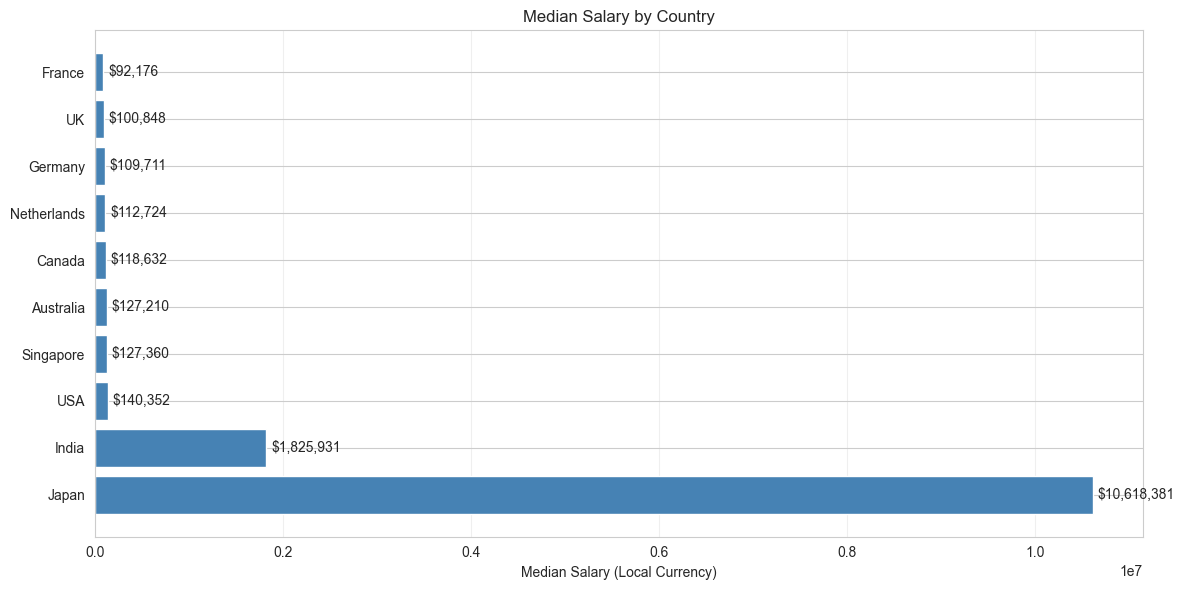

In [13]:
# Salary by country
country_salary = df.groupby('country').agg({
    'salary_local_currency': ['count', 'mean', 'median'],
    'job_satisfaction_score': 'mean'}).round(0)

country_salary.columns = ['job_count', 'avg_salary', 'median_salary', 'avg_satisfaction']
country_salary = country_salary.sort_values('median_salary', ascending = False)

print("\n" + "=" * 70)
print("SALARY BY COUNTRY")
print("=" * 70)
print(country_salary)

# Visualization
fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(country_salary.index, country_salary['median_salary'], color='steelblue')
ax.set_xlabel('Median Salary (Local Currency)')
ax.set_title('Median Salary by Country')
ax.grid(alpha=0.3, axis='x')

for i, v in enumerate(country_salary['median_salary']):
    ax.text(v + 50000, i, f'${v:,.0f}', va='center')

plt.tight_layout()
plt.savefig('../reports/05_country_salary.png', dpi=300, bbox_inches='tight')
plt.show()


## 10. Key Findings Summary

In [14]:
print("\n" + "=" * 70)
print("KEY FINDINGS FROM WEEK 1 EXPLORATION")
print("=" * 70)

# Finding 1: Top skill
top_skill = skill_salary.index[0]
top_skill_salary = skill_salary.iloc[0]['median_salary']
print(f"\n1. Highest-paying skill: {top_skill} (${top_skill_salary:,.0f} median)")

# Finding 2: Experience impact
entry_salary = exp_salary.loc['Entry', 'median_salary']
lead_salary = exp_salary.loc['Lead', 'median_salary']
increase = ((lead_salary - entry_salary) / entry_salary) * 100
print(f"\n2. Entry → Lead salary increase: {increase:.1f}% (${entry_salary:,.0f} → ${lead_salary:,.0f})")

# Finding 3: Company size
best_company = company_salary.index[0]
best_salary = company_salary.iloc[0]['median_salary']
print(f"\n3. Best-paying company size: {best_company} (${best_salary:,.0f})")

# Finding 4: Best country
best_country = country_salary.index[0]
best_country_salary = country_salary.iloc[0]['median_salary']
print(f"\n4. Highest-paying country: {best_country} (${best_country_salary:,.0f})")

# Finding 5: Satisfaction correlation
satisfaction_corr = df['salary_local_currency'].corr(df['job_satisfaction_score'])
print(f"\n5. Salary-satisfaction correlation: {satisfaction_corr:.3f} (weak positive)")

print("\n" + "=" * 70)


KEY FINDINGS FROM WEEK 1 EXPLORATION

1. Highest-paying skill: C++ ($136,733 median)

2. Entry → Lead salary increase: 157.3% ($79,169 → $203,696)

3. Best-paying company size: Startup ($135,964)

4. Highest-paying country: Japan ($10,618,381)

5. Salary-satisfaction correlation: 0.001 (weak positive)

